# yfinance Library Assignment  

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [2]:
# Code Here 
def download_historical_data(symbol, start_date, end_date, timeframe='1d'):
    ticker= yf.Ticker(symbol)
    historical_data = ticker.history(interval= timeframe, start= start_date, end= end_date)
    return historical_data

### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


In [21]:
# Code here 
def plot_closing_prices(historical_data, symbol):
    plt.figure(figsize=(12, 12))
    plt.plot(historical_data.index, historical_data['Close'], label='Close Price')
    plt.title(f'{symbol} Closing Prices')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

### Run the functions 

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

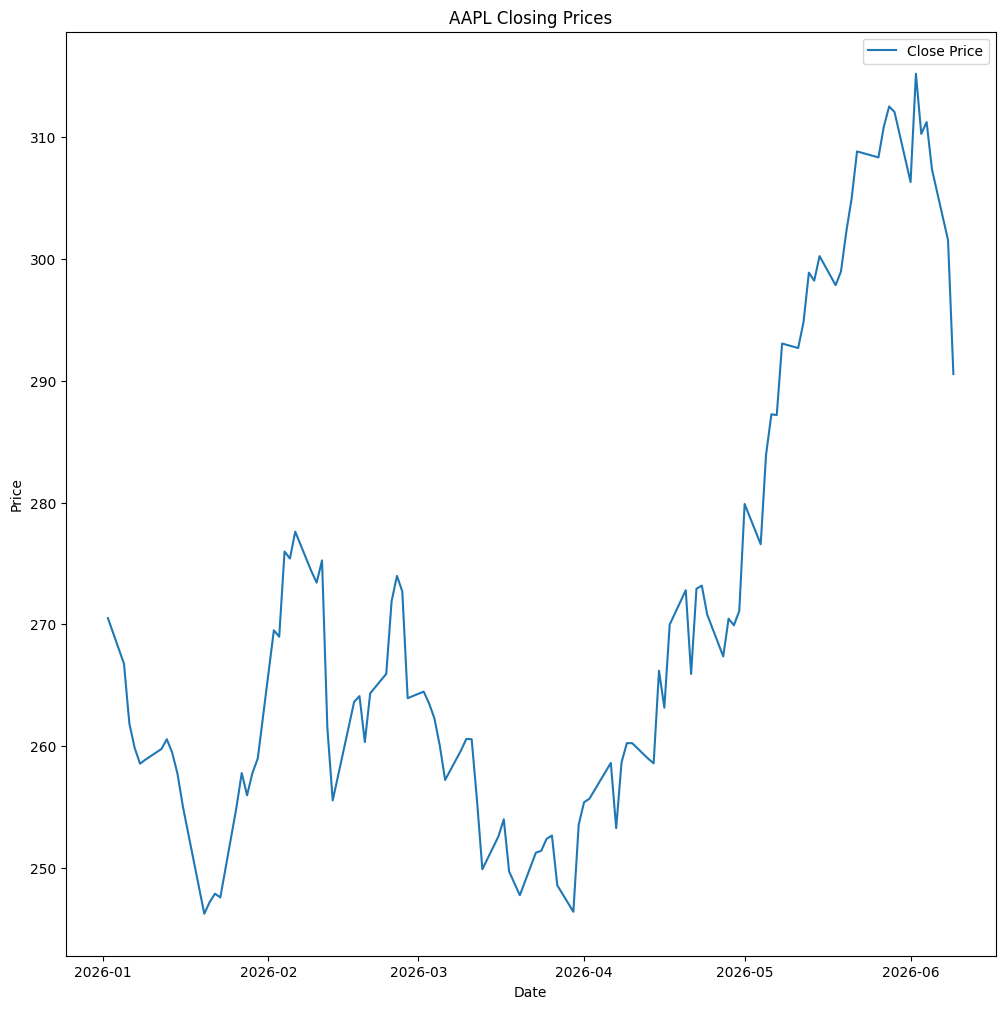

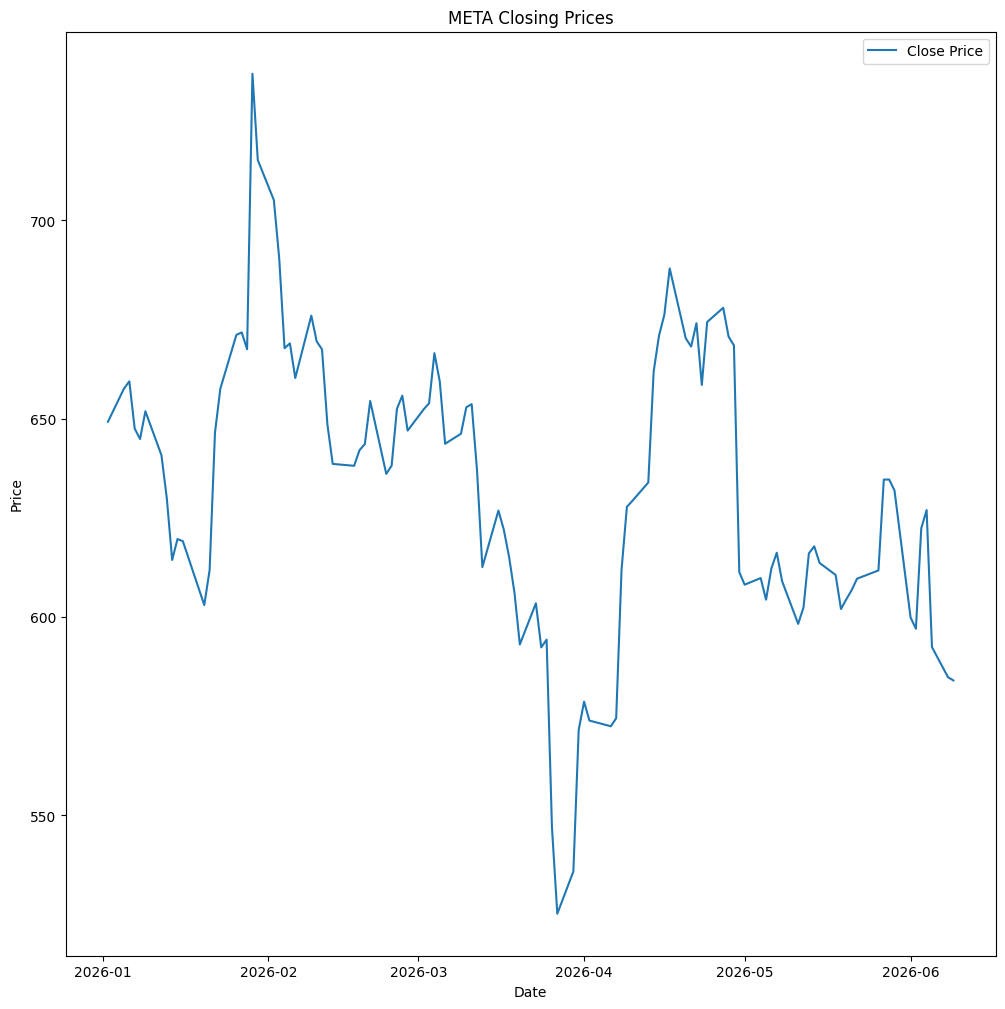

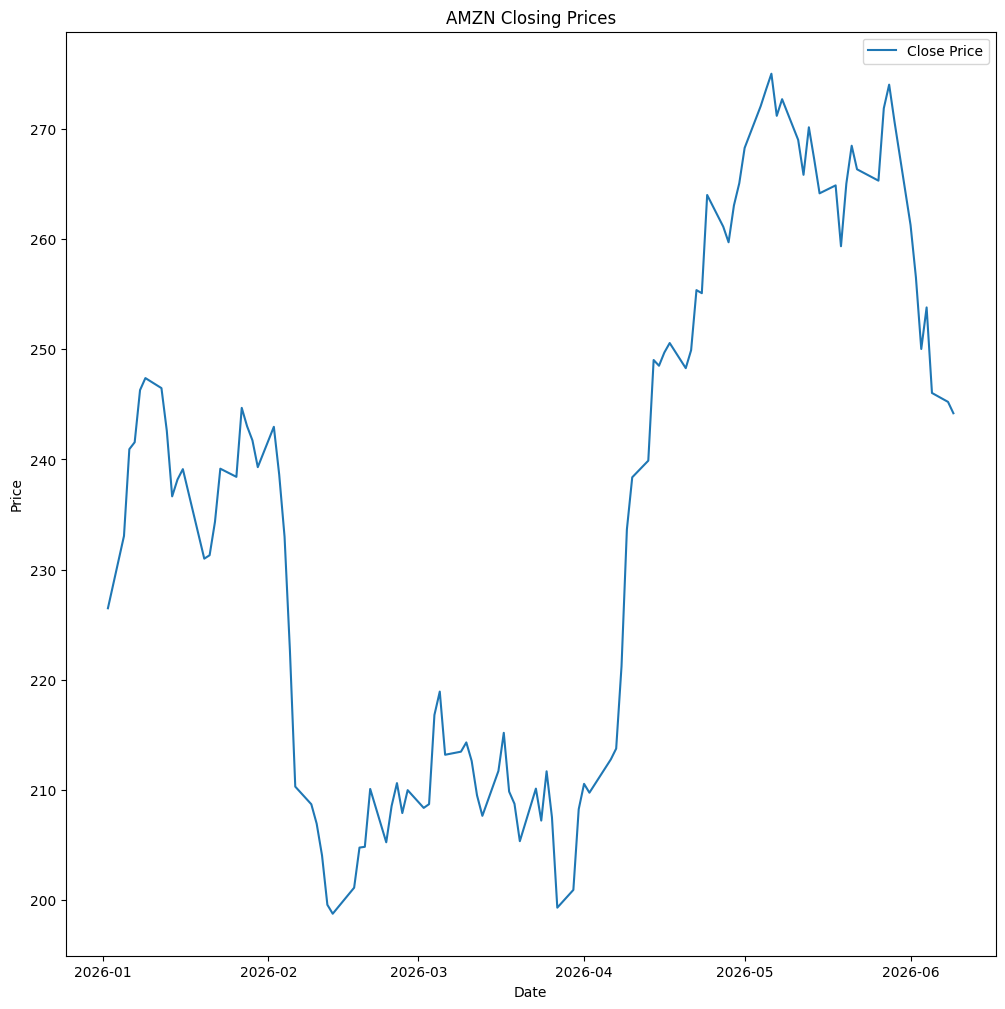

In [25]:
# Code here 

# plot_closing_prices(download_historical_data('AAPL', '2012-01-01', '2022-01-01'), 'AAPL')
# plot_closing_prices(download_historical_data('META', '2012-01-01', '2022-01-01'), 'META')
# plot_closing_prices(download_historical_data('AMZN', '2012-01-01', '2022-01-01'), 'AMZN')

plot_closing_prices(download_historical_data('AAPL', '2026-01-01', '2026-06-10'), 'AAPL') #doing the analysis for 2026
plot_closing_prices(download_historical_data('META', '2026-01-01', '2026-06-10'), 'META')
plot_closing_prices(download_historical_data('AMZN', '2026-01-01', '2026-06-10'), 'AMZN')

### Technical Analysis 

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph 
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

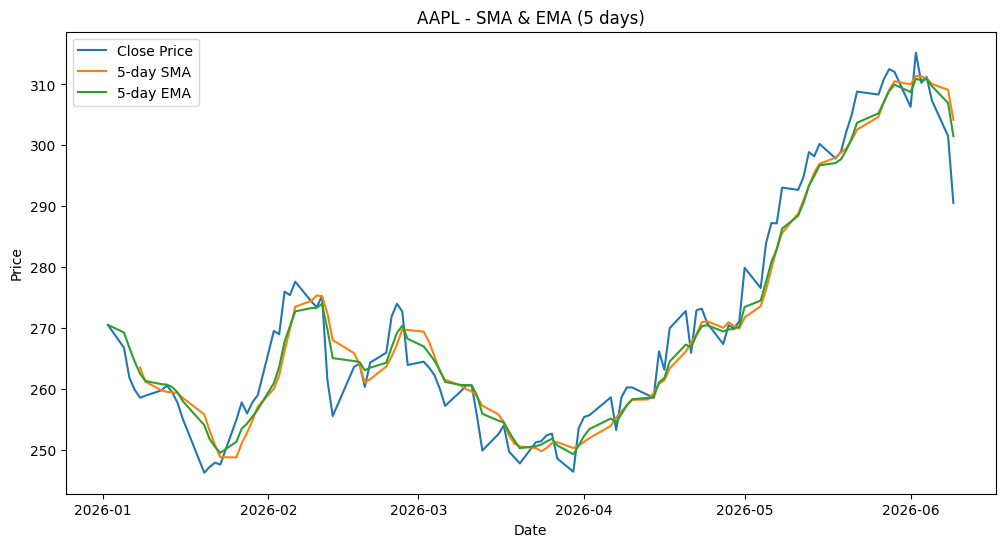

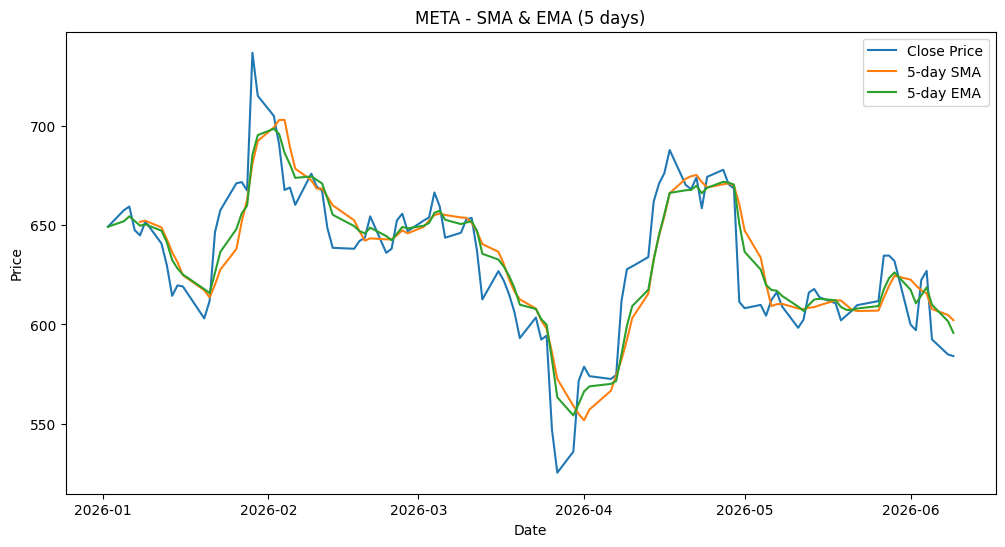

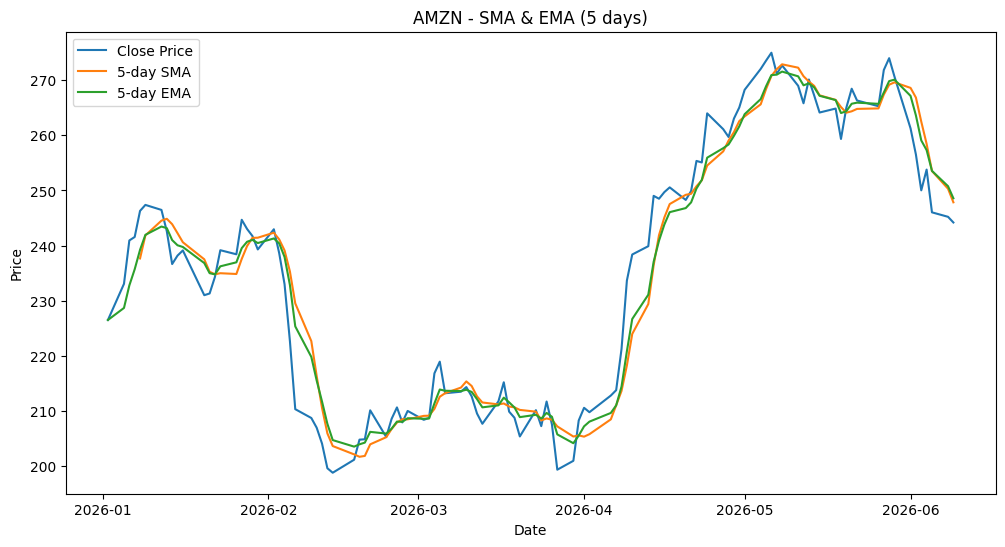

In [ ]:
# Code here 
def plot_sma_ema(historical_data, symbol, window=5):
    sma = historical_data['Close'].rolling(window=window).mean()
    ema = historical_data['Close'].ewm(span=window, adjust=False).mean()
    
    plt.figure(figsize=(12, 6))
    plt.plot(historical_data.index, historical_data['Close'], label='Close Price')
    plt.plot(historical_data.index, sma, label=f'{window}-day SMA')
    plt.plot(historical_data.index, ema, label=f'{window}-day EMA')
    plt.title(f'{symbol} - SMA & EMA ({window} days)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

plot_sma_ema(download_historical_data('AAPL', '2026-01-01', '2026-06-10'), 'AAPL') #for 2012 to 2022 the graph is almost overlapping due to zooming out of graph (longer interval)
plot_sma_ema(download_historical_data('META', '2026-01-01', '2026-06-10'), 'META')
plot_sma_ema(download_historical_data('AMZN', '2026-01-01', '2026-06-10'), 'AMZN')


**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

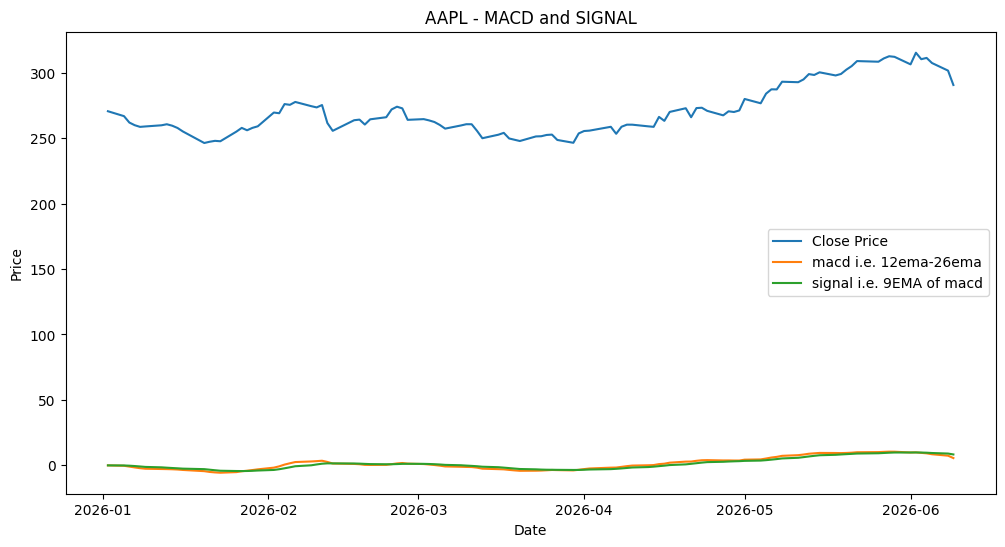

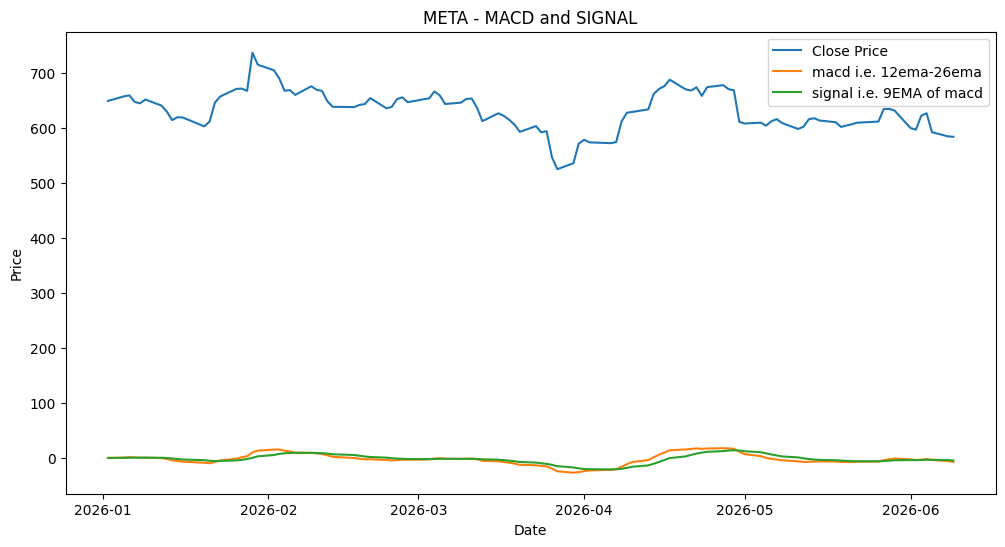

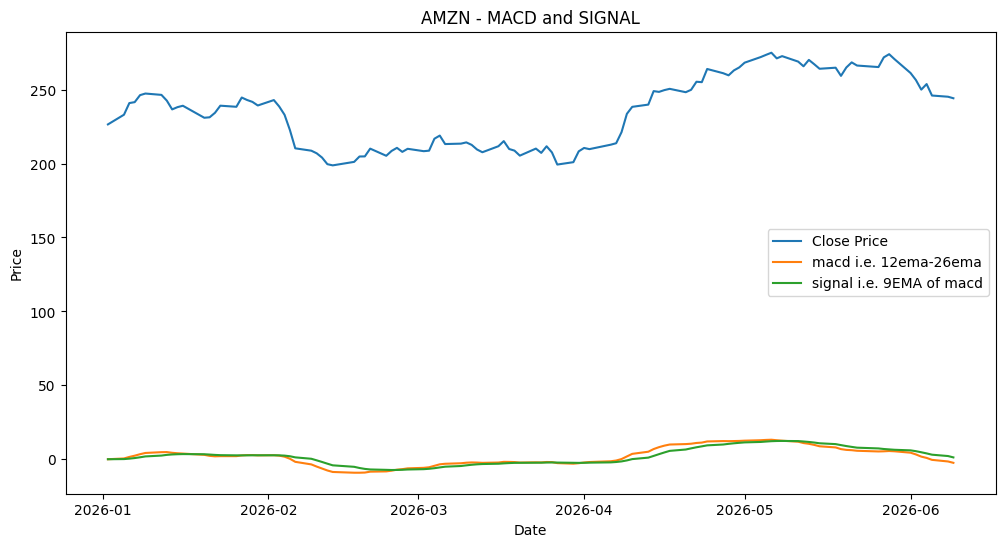

In [11]:
# Code Here

def plot_macd(historical_data, symbol):
    macd= historical_data['Close'].ewm(span=12, adjust=False).mean()-historical_data['Close'].ewm(span=26, adjust=False).mean()
    signal= macd.ewm(span=9, adjust=False).mean()
    
    plt.figure(figsize=(12, 6))
    plt.plot(historical_data.index, historical_data['Close'], label='Close Price')
    plt.plot(historical_data.index, macd, label='macd i.e. 12ema-26ema')
    plt.plot(historical_data.index, signal, label='signal i.e. 9EMA of macd')
    plt.title(f'{symbol} - MACD and SIGNAL')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()
    
    
plot_macd(download_historical_data('AAPL', '2026-01-01', '2026-06-10'), 'AAPL') 
plot_macd(download_historical_data('META', '2026-01-01', '2026-06-10'), 'META')
plot_macd(download_historical_data('AMZN', '2026-01-01', '2026-06-10'), 'AMZN')

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days 
   - Also show the overbought and oversold regions 
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

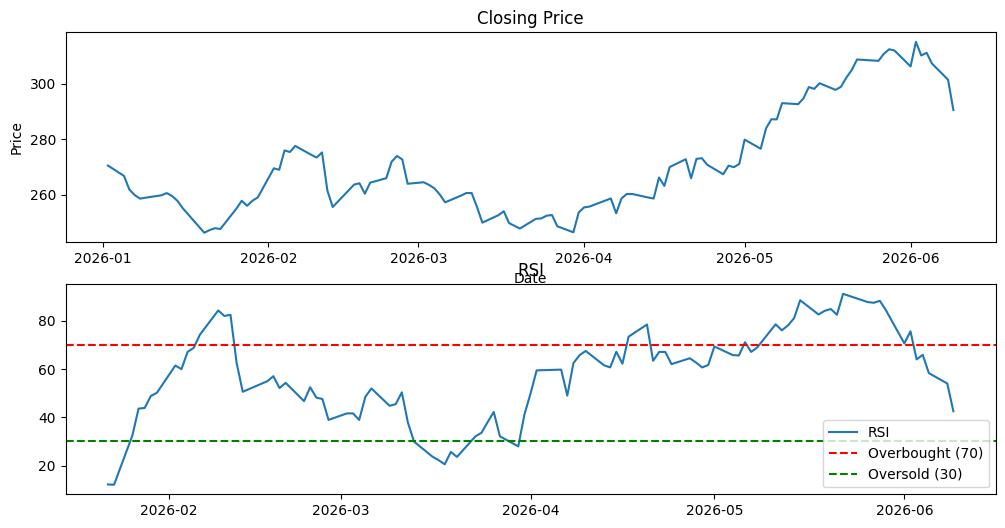

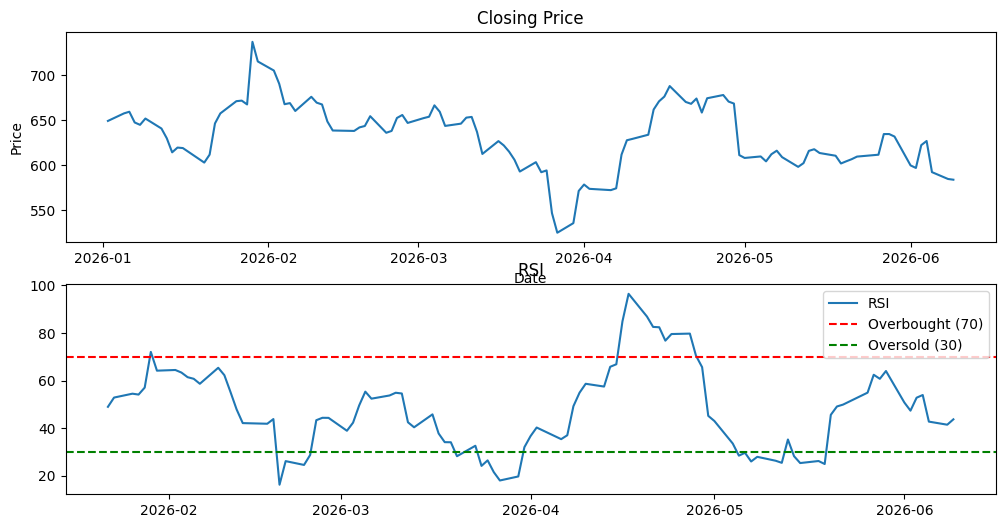

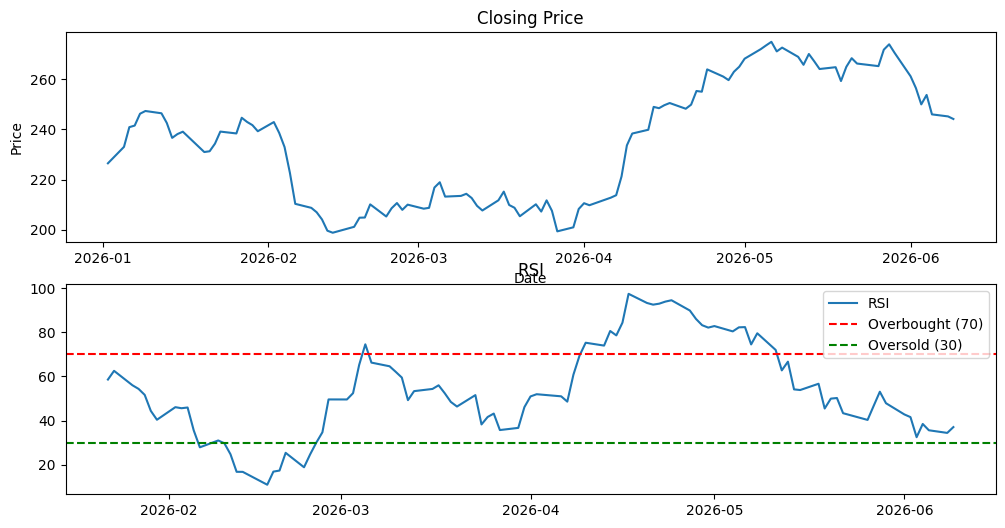

In [15]:
# Code here

def plot_rsi(historical_data, symbol, period=14):
    delta = historical_data['Close'].diff()
    
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    plt.figure(figsize=(12,6))
    plt.subplot(2,1,1)
    plt.plot(historical_data.index, historical_data['Close'], label='Close Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Closing Price')
    plt.subplot(2,1,2)
    plt.plot(historical_data.index, rsi, label='RSI')
    plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
    plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
    plt.title('RSI')
    plt.legend()
    plt.show()
    
plot_rsi(download_historical_data('AAPL', '2026-01-01', '2026-06-10'), 'AAPL') 
plot_rsi(download_historical_data('META', '2026-01-01', '2026-06-10'), 'META')
plot_rsi(download_historical_data('AMZN', '2026-01-01', '2026-06-10'), 'AMZN')

### Summarize your analysis

""" Write your answer here """

1. Since ive plotted a line graph, the analysis using candelsticks isnt possible.
2. Support and Resistance:
* AAPL: Support = 240, Resistance isnt clear for APPLE as it is in a continuous uptrend since a long time
* META: Resistance band: 675 to 775 in recent times
* AMZN: Support: around 200 and Resistance : around 270
3. For Amazon we can see a double top formation (Dow theory perspective). This indicates taking a long position
4. According to the simple moving averages, it seems that all three stocks are below average currently.
5. Amongst the technical indicators, only the RSI for Amazon shows that it is almost oversold indicating to go in a long position.

